In [2]:
#import the libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
#checking the duploactes
df.duplicated().sum()
#their is no duplocate data in the  dataset

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (545, 13)


In [12]:
print("mainroad: " , df['mainroad'].unique())
print("Guestroom:", df["guestroom"].unique())
print("Basement:", df["basement"].unique())
print("Air Conditioning:", df["airconditioning"].unique())
print("Furnishing:", df["furnishingstatus"].unique())
#checking the categorical unique values for each column

mainroad:  ['yes' 'no']
Guestroom: ['no' 'yes']
Basement: ['no' 'yes']
Air Conditioning: ['yes' 'no']
Furnishing: ['furnished' 'semi-furnished' 'unfurnished']


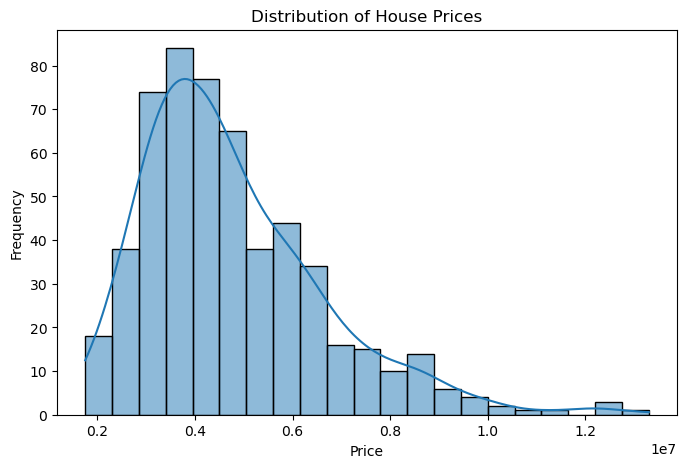

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"],kde = True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

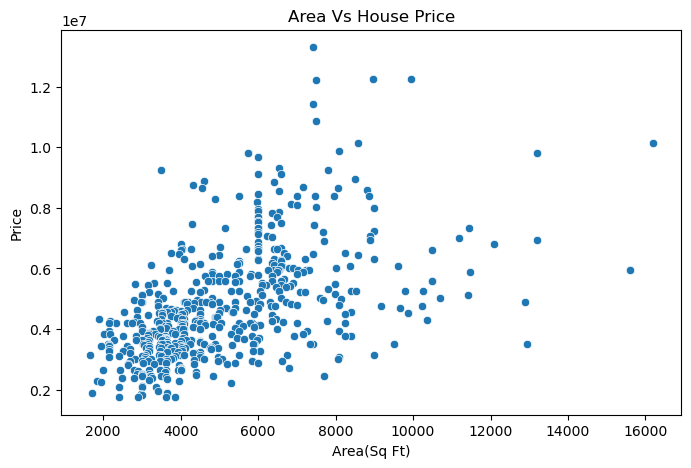

In [14]:
#Area vs Price checking 
plt.figure(figsize=(8,5))
sns.scatterplot(
    data = df,
    x = "area",
    y = "price"
)
plt.title("Area Vs House Price")
plt.xlabel("Area(Sq Ft)")
plt.ylabel("Price")
plt.show()

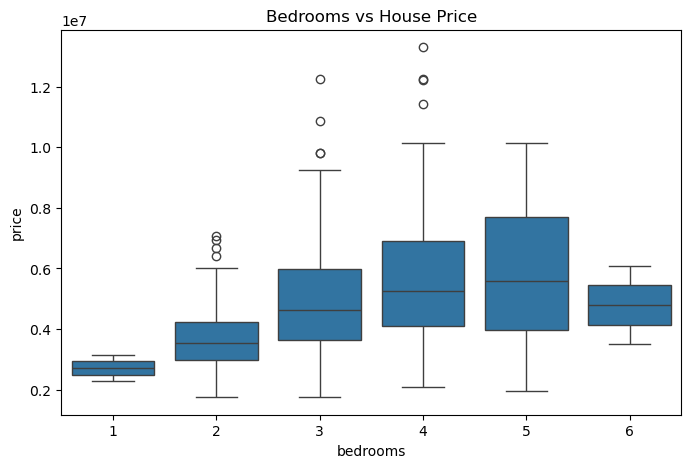

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data = df,
    x = "bedrooms",
    y = "price"
)
plt.title("Bedrooms vs House Price")
plt.show()

In [16]:
#correlation analysis 
numeric_df = df.select_dtypes(include=np.number)

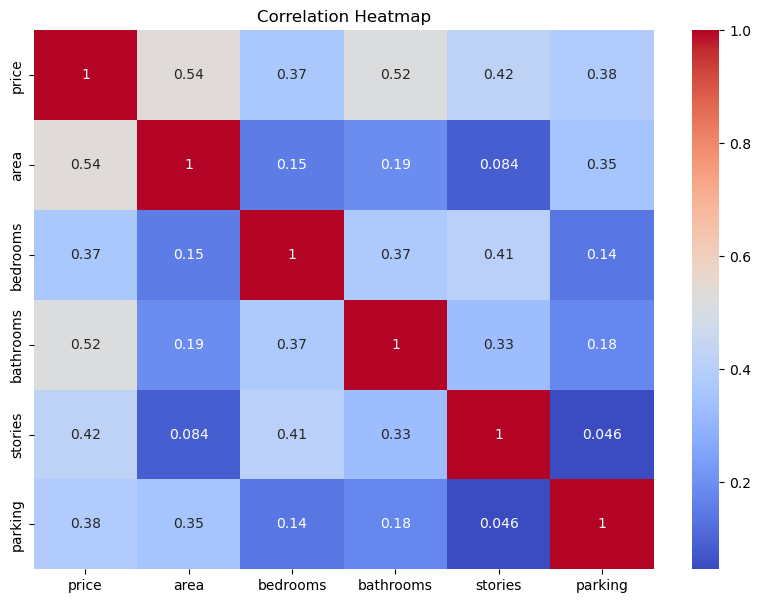

In [17]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
X  = df.drop("price",axis=1)
y = df["price"]

In [19]:
#Encoding the categorical data 
categorical_columns = X.select_dtypes(
    include=['object']
).columns

print(categorical_columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [20]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [21]:
# Convert True/False to 1/0
X = X.astype(int)

In [22]:
print("\nEncoded dataset:")
display(X.head())


Encoded dataset:


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [23]:
print(X.columns.tolist())
print(X.shape)

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
(545, 13)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [25]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 13)
X_test : (109, 13)
y_train: (436,)
y_test : (109,)


In [26]:
#creating the linear regression model
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,area,2.359688e+02
1,bedrooms,7.677870e+04
2,bathrooms,1.094445e+06
3,stories,4.074766e+05
4,parking,2.248419e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
7,basement_yes,3.902512e+05
8,hotwaterheating_yes,6.846499e+05
9,airconditioning_yes,7.914267e+05


In [28]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [29]:
print("Intercept:", model.intercept_)

Intercept: 260032.35760740843


In [30]:
#make the prediction of the model
y_pred = model.predict(X_test)

In [32]:
#display 
results = pd.DataFrame(
    {
        "Actual Price": y_test.values,
        "Predicted Price": y_pred
    }
)
results.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


In [33]:
#now we evaluate the model
mae = mean_absolute_error(y_test,y_pred)
print("MAE :", mae)

MAE : 970043.4039201635


In [34]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1754318687330.663


In [35]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1324506.9600914384


In [36]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6529242642153186


In [37]:
print("MODEL PERFORMANCE")
print("========================")

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MODEL PERFORMANCE
MAE  : 970,043.40
MSE  : 1,754,318,687,330.66
RMSE : 1,324,506.96
R²   : 0.6529


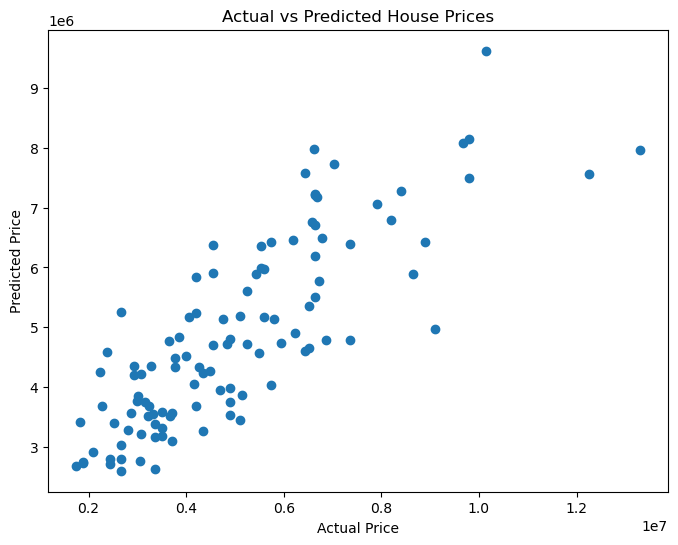

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [39]:
residuals = y_test - y_pred

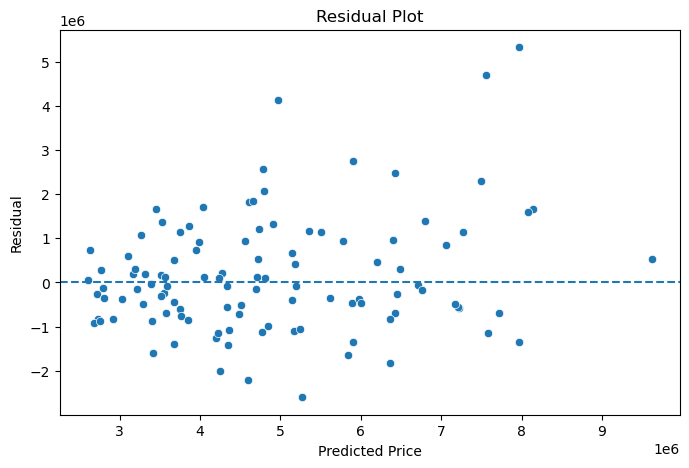

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [41]:
# we are now using these model to evaluate the new dataset
new_house = pd.DataFrame({
    "area": [6000],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "mainroad": ["yes"],
    "guestroom": ["no"],
    "basement": ["yes"],
    "hotwaterheating": ["no"],
    "airconditioning": ["yes"],
    "parking": [2],
    "prefarea": ["yes"],
    "furnishingstatus": ["semi-furnished"]
})

In [42]:
new_house = pd.get_dummies(
    new_house,
    columns=categorical_columns,
    drop_first=True
)

In [43]:
new_house = new_house.reindex(
    columns=X.columns,
    fill_value=0
)

In [44]:
predicted_price = model.predict(new_house)

print(
    "Predicted House Price:",
    predicted_price[0]
)

Predicted House Price: 5359707.878483189


In [45]:
import joblib

joblib.dump(
    model,
    "house_price_linear_regression.pkl"
)

['house_price_linear_regression.pkl']

In [46]:
loaded_model = joblib.load(
    "house_price_linear_regression.pkl"
)

In [47]:
prediction = loaded_model.predict(new_house)

print("Predicted Price:", prediction[0])

Predicted Price: 5359707.878483189
